References:
- https://trinhngocthuyen.com/posts/tech/a-dive-into-hog/
- https://stackoverflow.com/questions/67243124/python-skimage-feature-hog-function-meaning-of-parameter-pixels-per-cell-and-ce
- https://thepythoncode.com/article/hog-feature-extraction-in-python
- https://stackoverflow.com/questions/55466298/pytorch-cant-call-numpy-on-variable-that-requires-grad-use-var-detach-num

In [3]:
# https://trinhngocthuyen.com/posts/tech/a-dive-into-hog/
# https://stackoverflow.com/questions/67243124/python-skimage-feature-hog-function-meaning-of-parameter-pixels-per-cell-and-ce
# https://thepythoncode.com/article/hog-feature-extraction-in-python


In [4]:
%%capture
%pip install torch torchvision torchaudio
%pip install scipy
%pip install numpy
%pip install pandas
%pip install opencv-python
%pip install matplotlib
%pip install scikit-image

In [5]:
import torch
import torchvision
from pathlib import Path
import pickle
import numpy as np
import scipy
import math
import cv2
import PIL

### Load Database

Files already downloaded and verified
<class 'torchvision.datasets.caltech.Caltech101'>


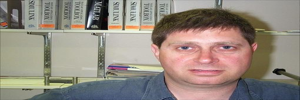

In [6]:
db = torchvision.datasets.Caltech101("./",  download=True)
print(type(db))
db
image = db[0][0].resize((300,100))
display(image)

data_dict = {}
data_dict["Image"] = image
data_dict["Index"] = 0

### Color Moments

In [7]:
# All code generated by a version of ChaptGPT with some personal modifications as I couldn't find packages/pretrianed models & for reference only
import torch
from PIL import Image
from scipy.stats import skew
import numpy as np

img = image

# Convert image to PyTorch tensor
img_tensor = torch.from_numpy(np.array(img))

# Partition the image into 10x10 grid
grid = img_tensor.unfold(0, 10, 10).unfold(1, 10, 10)

# Initialize feature descriptor
descriptor = torch.empty((10, 10, 3, 3))
print(len(grid), len(grid[0]), len(grid[0][0]))
# Compute color moments for each grid cell
for i in range(10):
    for j in range(30):
        for k in range(3):
            cell = grid[i, j, :, k].float()
            break
            descriptor[i, j, k, 0] = torch.mean(cell) # Mean
            descriptor[i, j, k, 1] = torch.std(cell) # Standard deviation
            descriptor[i, j, k, 2] = skew(cell.flatten()) # Skewness

# Reshape to obtain a unified 900 dimensional feature descriptor
descriptor = descriptor.view(-1)
print(len(descriptor))

data_dict["CM"] = [descriptor]

10 30 3
900


### HOG

In [8]:
# All code generated by a version of ChaptGPT with some personal modifications as I couldn't find packages/pretrianed models & for reference only
import torch
from PIL import Image
import numpy as np

# Convert image to grayscale
img_gray = img.convert('L')

# Convert image to PyTorch tensor
img_tensor = torch.from_numpy(np.array(img_gray)).float()

# Define Sobel filters
sobel_x = torch.tensor([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]]).float()
sobel_y = torch.tensor([[-1, -2, -1], [0, 0, 0], [1, 2, 1]]).float()

# Compute gradients
gradient_x = torch.nn.functional.conv2d(img_tensor.unsqueeze(0).unsqueeze(0), sobel_x.unsqueeze(0).unsqueeze(0), padding=1)
gradient_y = torch.nn.functional.conv2d(img_tensor.unsqueeze(0).unsqueeze(0), sobel_y.unsqueeze(0).unsqueeze(0), padding=1)

# Compute gradient magnitude and orientation
magnitude = torch.sqrt(gradient_x**2 + gradient_y**2)
orientation = torch.atan2(gradient_y, gradient_x)

# Initialize feature descriptor
descriptor = torch.empty((10, 10, 9))

# Compute histogram for each grid cell
for i in range(10):
    for j in range(10):
        cell_magnitude = magnitude[0, i*30:(i+1)*30, j*10:(j+1)*10]
        cell_orientation = orientation[0, i*30:(i+1)*30, j*10:(j+1)*10]
        # Map orientation to bin
        bin = torch.floor(cell_orientation / (np.pi/9)).long() % 9
        # Compute histogram
        descriptor[i, j] = torch.bincount(bin.view(-1), weights=cell_magnitude.view(-1), minlength=9)

print(len(descriptor), len(descriptor[0]), len(descriptor[0][0]))

data_dict["HOG"] = [descriptor]

10 10 9


### Resnet

In [9]:
# All code generated by a version of ChaptGPT with some personal modifications as I couldn't find packages/pretrianed models & for reference only
import torch
from torchvision import models, transforms
from PIL import Image
import numpy as np

# Load image
img = image

# Define transform
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Apply transform to image
img_tensor = transform(img).unsqueeze(0)

# Check if CUDA is available and if so, use GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using Device:", str(device))
img_tensor = img_tensor.to(device)

# Load pre-trained ResNet50 model
model = models.resnet50(weights=torchvision.models.ResNet50_Weights.DEFAULT)
model.zero_grad(set_to_none=True)
model = model.to(device)
model.eval()
print("Model Loaded")

Using Device: cpu
Model Loaded


In [10]:
# All code generated by a version of ChaptGPT with some personal modifications as I couldn't find packages/pretrianed models & for reference only

# Define hook for avgpool layer
def hook(module, input, output):
    global avgpool_output
    avgpool_output = output.view(output.size(0), -1)

handle = model.avgpool.register_forward_hook(hook)

# Forward pass image through model
output = model(img_tensor)

# Remove hook
handle.remove()

# Reduce dimensionality of avgpool output by averaging two consecutive entries
avgpool_output_reduced = (avgpool_output[:, ::2] + avgpool_output[:, 1::2]) / 2

print(avgpool_output_reduced.shape)  # Should be [1, 1024]

data_dict["AvgPool"] = [avgpool_output_reduced]

torch.Size([1, 1024])


In [11]:
# All code generated by a version of ChaptGPT with some personal modifications as I couldn't find packages/pretrianed models & for reference only

# Define hook for layer3
def hook(module, input, output):
    global layer3_output
    layer3_output = output

handle = model.layer3.register_forward_hook(hook)

# Forward pass image through model
output = model(img_tensor)

# Remove hook
handle.remove()

# Convert tensor to vector by averaging each 14x14 slice
layer3_output_vector = layer3_output.mean([2, 3])

print(layer3_output_vector.shape)  # Should be [1, 1024]

data_dict["Layer3"] = [layer3_output_vector]


torch.Size([1, 1024])


In [12]:
# All code generated by a version of ChaptGPT with some personal modifications as I couldn't find packages/pretrianed models & for reference only

# Define hook for fc layer
def hook(module, input, output):
    global fc_output
    fc_output = output

handle = model.fc.register_forward_hook(hook)

# Forward pass image through model
output = model(img_tensor)

# Remove hook
handle.remove()

print(fc_output.shape)  # Should be [1, 1000]

data_dict["FC"] = [fc_output]


torch.Size([1, 1000])


#### Export Results

In [14]:
import pandas as pd
df = pd.DataFrame()
with torch.no_grad():
    df = pd.DataFrame(data_dict)

df.head(1)


,Image,Index,CM,HOG,AvgPool,Layer3,FC
0,<PIL.Image.Image image mode=RGB size=300x100 a...,0,"[tensor(3.7630e-14), tensor(1.3563e-19), tenso...","[[[tensor(99026.3438), tensor(17120.5703), ten...","[[tensor(0.0002, grad_fn=<UnbindBackward0>), t...","[[tensor(0.4289, grad_fn=<UnbindBackward0>), t...","[[tensor(2.1171, grad_fn=<UnbindBackward0>), t..."


#### Display Results

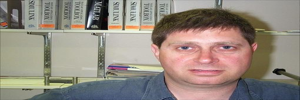

In [21]:
display(df["Image"].values[0])